# DBI Test: $H_0$ with diagonal entries being 0

This notebook serves to explore the behavior of initial Hamiltonian with all 0 diagonal entries under double bracket rotations.

In [3]:
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math
import seaborn as sns

from qibo import hamiltonians, set_backend
from qibo.hamiltonians import Hamiltonian, SymbolicHamiltonian
from qibo.quantum_info import random_hermitian
from qibo.models.dbi.double_bracket import DoubleBracketGeneratorType, DoubleBracketScheduling, DoubleBracketIteration
from qibo.models.dbi.utils import *

In [4]:
def visualize_matrix(matrix, title=""):
    """Visualize hamiltonian in a heatmap form."""
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_title(title)
    try:
        im = ax.imshow(np.absolute(matrix), cmap="inferno")
    except TypeError:
        im = ax.imshow(np.absolute(matrix.get()), cmap="inferno")
    fig.colorbar(im, ax=ax)

In [13]:
# Random hamiltonian
set_backend("qibojit", "numba")
seed = 1
nqubits = 5
H_random = Hamiltonian(nqubits=nqubits, matrix=random_hermitian(2**nqubits, seed=seed))
dbi = DoubleBracketIteration(deepcopy(H_random))
dbi.h.matrix = dbi.off_diag_h

[Qibo 0.2.5|INFO|2024-03-15 17:42:22]: Using qibojit (numba) backend on /CPU:0


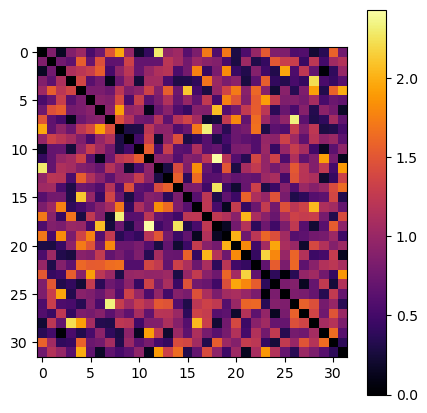

In [14]:
visualize_matrix(dbi.h.matrix)

In [16]:
step = dbi.polynomial_step()
print(step)

(None, [0j, 0j, 0j])
